In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_casecontrol_volcano(
    concat_df: pd.DataFrame,
    cell_type: str,
    fdr_alpha: float = 0.05,
    label_n: int = 12,
    hue_col: str = "selected_fdr_0.05",
    savepath: str | None = None,
    ax=None,
):
    """
    Volcano-style plot for one cell type from the 'concat' results table.

    Parameters
    ----------
    concat_df : pd.DataFrame
        Long table with columns: ['Unnamed: 0' (cell type), 'feature', 'posterior_mean', 'qvalue', hue_col].
    cell_type : str
        Which cell type to plot (matches values in concat_df['Unnamed: 0']).
    fdr_alpha : float
        Horizontal guideline at -log10(fdr_alpha).
    label_n : int
        Number of top up/down features to label.
    hue_col : str
        Column used for hue (True/False for FDR pass).
    savepath : str | None
        If provided, save the figure here.
    ax : matplotlib axis | None
        If provided, draw on this axis.
    """
    df = concat_df[concat_df['Unnamed: 0'] == cell_type].copy()

    # numeric + clean
    df["qvalue"] = pd.to_numeric(df["qvalue"], errors="coerce")
    df["posterior_mean"] = pd.to_numeric(df["posterior_mean"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["posterior_mean", "qvalue"])

    # safe -log10 transform
    if (df["qvalue"] > 0).any():
        min_q = max(1e-300, np.nanmin(df.loc[df["qvalue"] > 0, "qvalue"]) * 0.1)
    else:
        min_q = 1e-300
    df["_qplot"] = -np.log10(np.clip(df["qvalue"].values, min_q, 1.0))

    # plotting
    if ax is None:
        sns.set(style="whitegrid", context="talk")
        fig, ax = plt.subplots(figsize=(9, 7))
    palette = {True: "#d62728", False: "#c5c6c8"}

    sns.scatterplot(
        data=df,
        x="posterior_mean",
        y="_qplot",
        hue=hue_col,
        palette=palette,
        s=55,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
    )

    # cosmetics
    ax.set_title(f"{cell_type}: mtDSB vs Control", pad=14, fontsize=18, fontweight="bold")
    ax.set_xlabel("Posterior mean (effect size)", fontsize=14)
    ax.set_ylabel(r"$-\log_{10}(\mathrm{q\text{-}value})$", fontsize=14)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.axhline(-np.log10(fdr_alpha), color="#444", ls=":", lw=1)
    ax.legend(title="FDR < 0.05", frameon=False, loc="upper right")

    # labels
    top_up = df[df["posterior_mean"] > 0].nlargest(label_n, "posterior_mean")
    top_down = df[df["posterior_mean"] < 0].nsmallest(label_n, "posterior_mean")

    for _, row in top_up.iterrows():
        ax.text(row["posterior_mean"], row["_qplot"] + 0.05, row["feature"],
                fontsize=9, color="#d62728", ha="left", va="bottom")
    for _, row in top_down.iterrows():
        ax.text(row["posterior_mean"], row["_qplot"] + 0.05, row["feature"],
                fontsize=9, color="#1f6feb", ha="right", va="bottom")

    sns.despine(trim=True)
    plt.tight_layout()

    if savepath:
        ax.figure.savefig(savepath, dpi=300, bbox_inches="tight")

    return ax

In [50]:
concat = pd.read_csv('../results/baysian_diff_condition.csv')

In [60]:
cells = concat['Unnamed: 0'].unique()

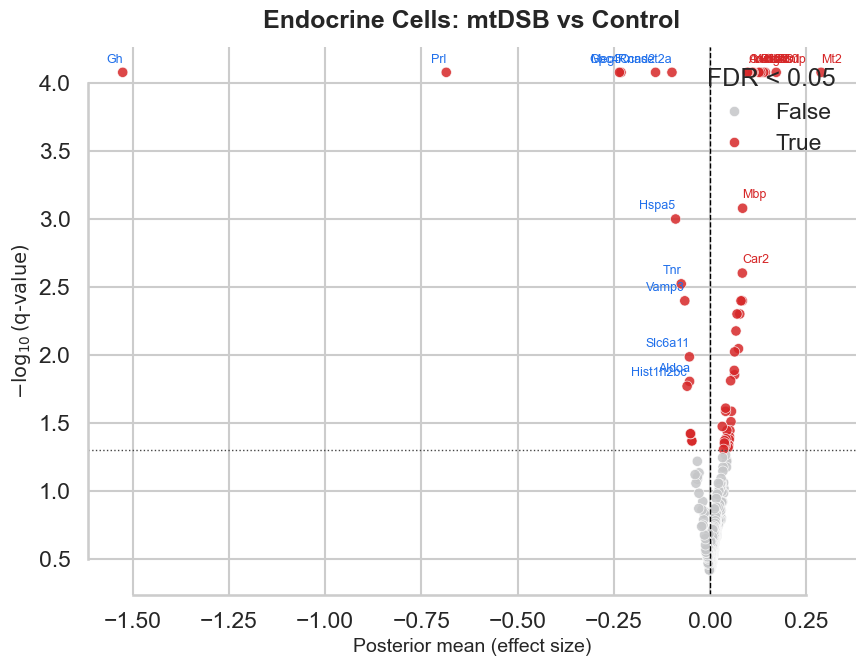

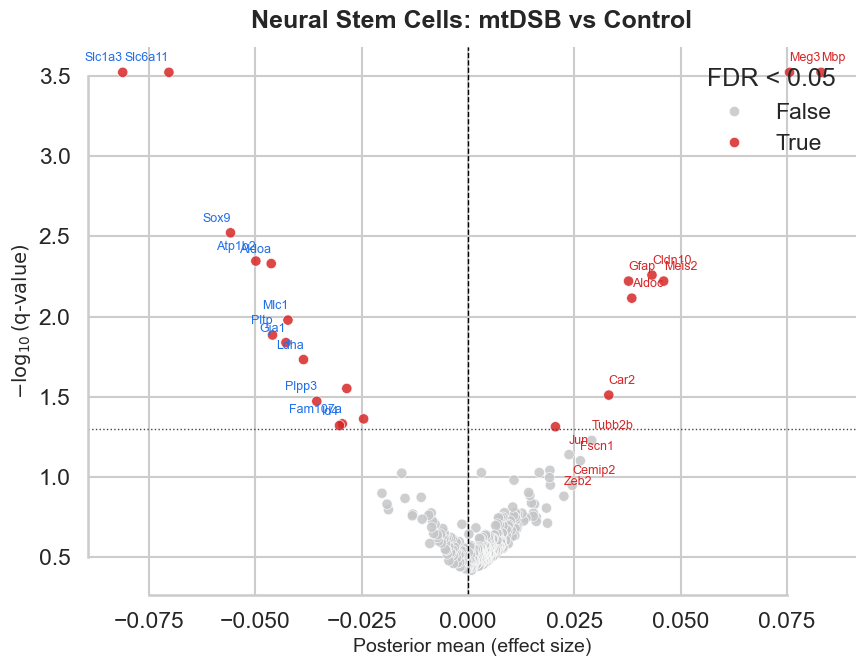

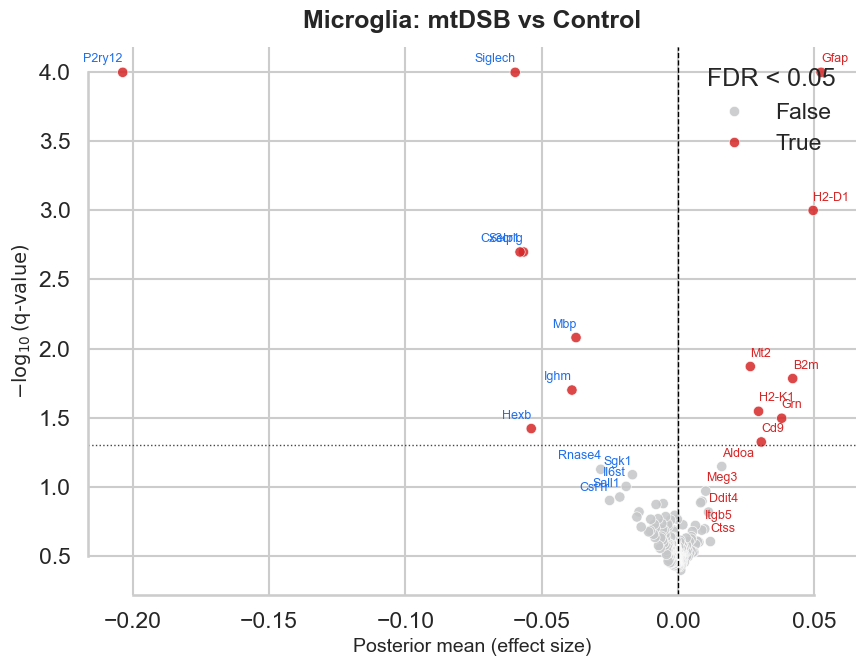

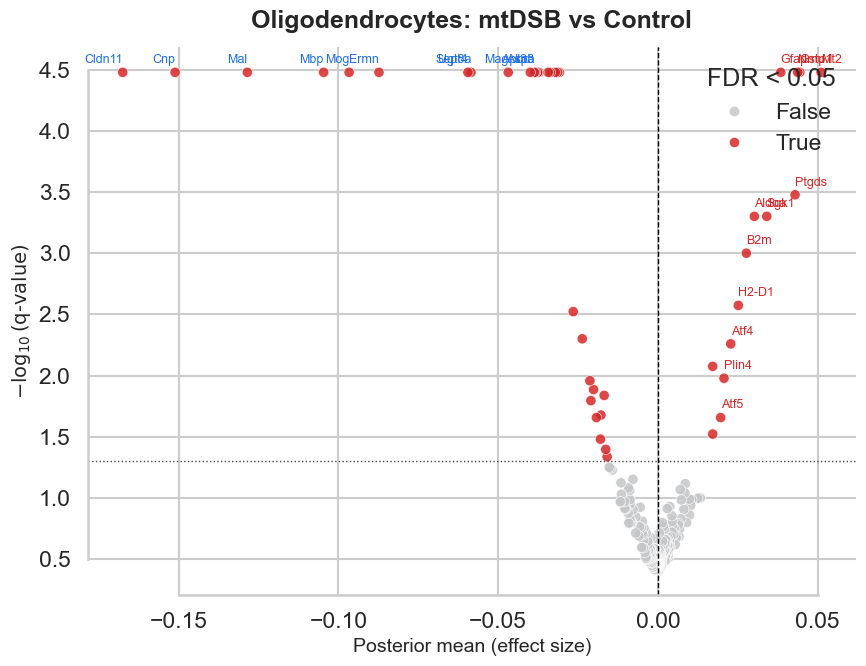

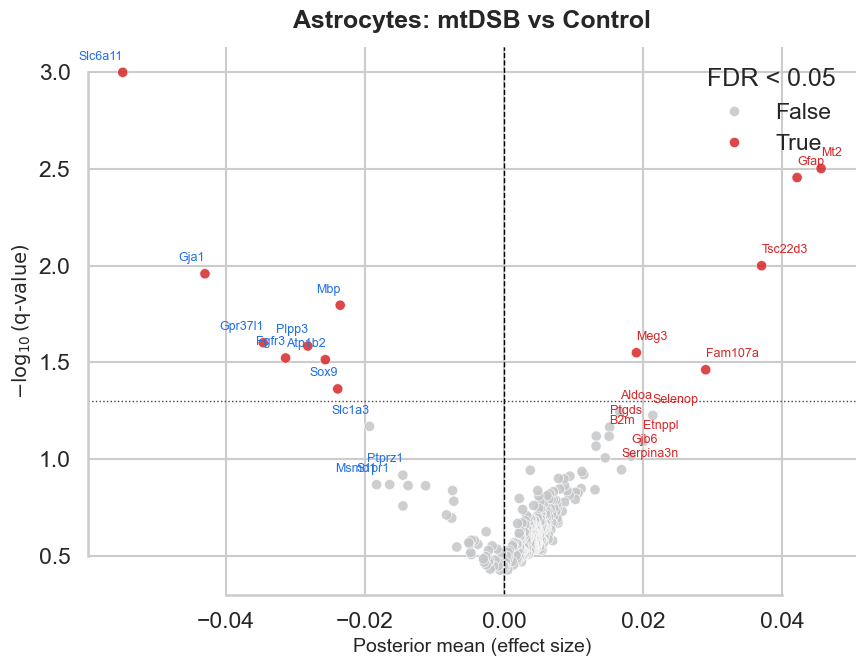

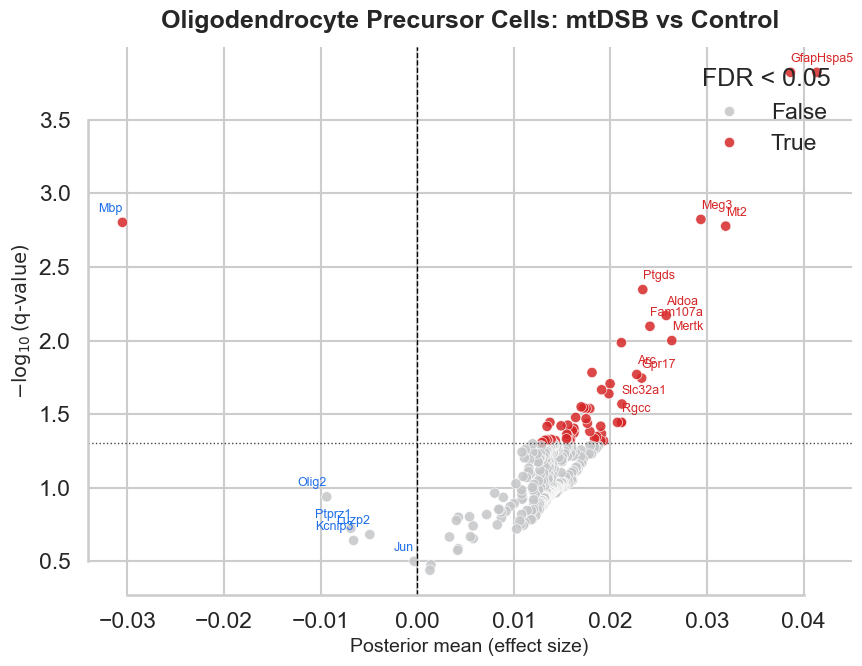

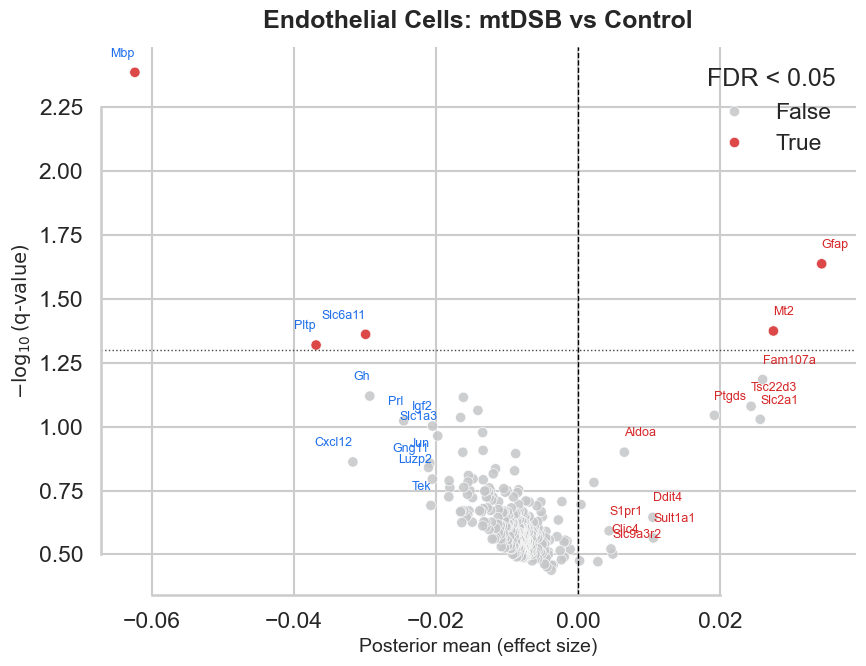

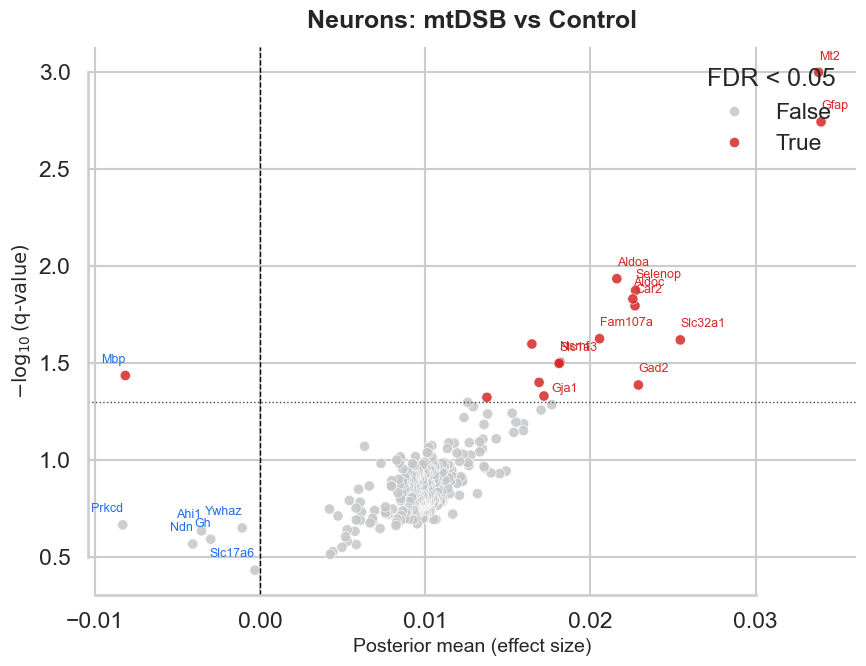

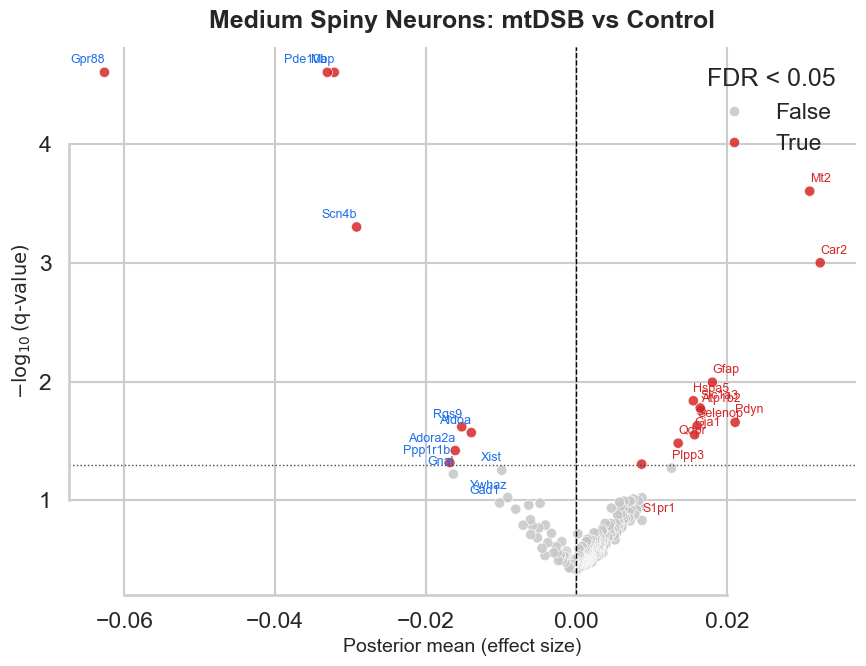

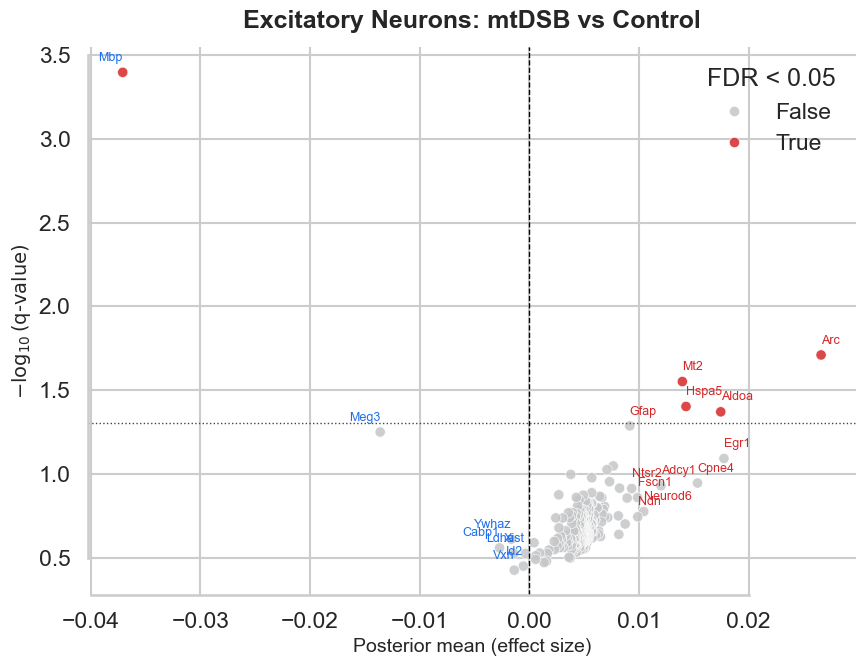

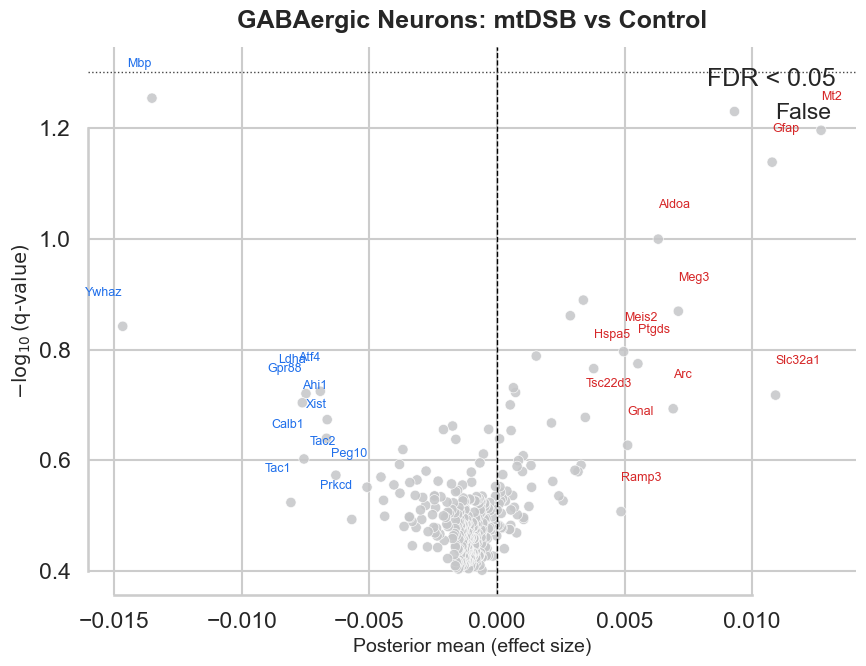

In [61]:
for cell in cells:
    ax = plot_casecontrol_volcano(concat, cell_type=cell, fdr_alpha=0.05, label_n=12)
    plt.show()

In [62]:
df_oligo = concat[concat['Unnamed: 0'] == 'Oligodendrocytes']
df_oligo[['posterior_mean','posterior_sd']].describe()

,posterior_mean,posterior_sd
count,360.000000,360.000000
mean,-0.003446,0.010146
std,0.019571,0.000530
min,-0.167490,0.008714
25%,-0.002301,0.010016
50%,-0.000625,0.010247
75%,0.000579,0.010332
max,0.051063,0.015241
